In [2]:
#imports
import sys
sys.path.append("/user/christoph.wald/u15287/insect_pest_detection/modules")
import cv2
import matplotlib.pyplot as plt
from modules_segmentation import *
from modules_augmentation import *
import random
import os

In [14]:
def show(img, title = None):
    '''
    plot an an cv2 image
    for use in notebooks
    '''
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.axis('off')
    if title: plt.title(title) 
    plt.show()

In [3]:
img = cv2.imread("/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/images/BRAIIM_0192.jpg")
cv2.imwrite("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/examples/a_braiim.jpg",img,  [cv2.IMWRITE_JPEG_QUALITY, 25])
img = cv2.imread("/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/images/FRANOC_0170.jpg")
cv2.imwrite("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/examples/b_franoc.jpg",img,  [cv2.IMWRITE_JPEG_QUALITY, 25])
img = cv2.imread("/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/images/LIRIBO_0616.jpg")
cv2.imwrite("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/examples/c_liribo.jpg",img,  [cv2.IMWRITE_JPEG_QUALITY, 25])
img = cv2.imread("/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/images/TRIAVA_0608.jpg")
cv2.imwrite("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/examples/d_triava.jpg",img,  [cv2.IMWRITE_JPEG_QUALITY, 25])

True

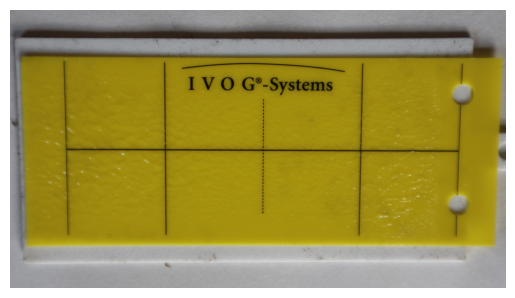

True

In [70]:
#emptyYST
image_folder = "/user/christoph.wald/u15287/big-scratch/emptyYST"
image_files = os.listdir(image_folder)
empty_YSTs = []
for f in image_files:
    empty_YSTs.append(cv2.imread(os.path.join(image_folder, f)))
show(empty_YSTs[0])
cv2.imwrite("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/examples/01_empty.jpg", empty_YSTs[0],  [cv2.IMWRITE_JPEG_QUALITY, 25])


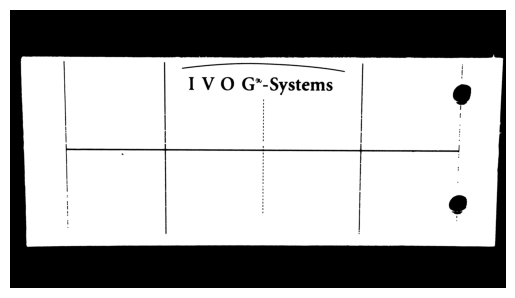

True

In [71]:
#binarized and cleaned YST
mask = create_binary_mask(empty_YSTs[0])
cleaned_mask = denoise_mask(mask)
show(cleaned_mask)
cv2.imwrite("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/examples/02_empty_binary.jpg", cleaned_mask,  [cv2.IMWRITE_JPEG_QUALITY, 25])


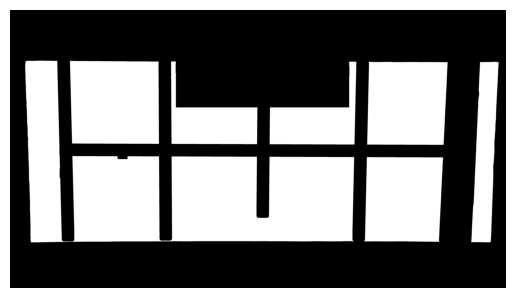

True

In [72]:
#thickened lines
fat_mask = cv2.imread("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/masks/06_generated_mask_fat_plus.jpg")
show(fat_mask)
cv2.imwrite("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/examples/03_empty_fat_mask.jpg", fat_mask,  [cv2.IMWRITE_JPEG_QUALITY, 25])


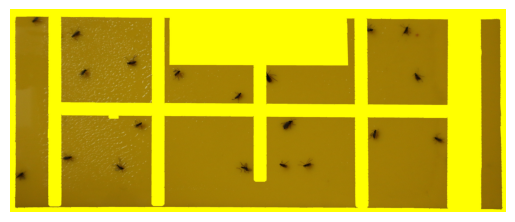

True

In [73]:
#overlay to an acutal image
image_masked = cv2.imread("/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/03_images_masked/BRAIIM_0003.jpg")
show(image_masked)
cv2.imwrite("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/examples/04_masked_image.jpg", image_masked,  [cv2.IMWRITE_JPEG_QUALITY, 25])


In [33]:
#binarized
min_area_contour = 2000 
max_area_contour = 10000
binary_default = True

inverted_mask = cv2.bitwise_not(create_binary_mask(image_masked, binary_default), )
contours, _ = cv2.findContours(inverted_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img_contours = cv2.cvtColor(inverted_mask, cv2.COLOR_GRAY2BGR)

for i, c in enumerate(contours):
    if cv2.contourArea(c) > min_area_contour and cv2.contourArea(c) < max_area_contour:
        # Draw contour
        cv2.drawContours(img_contours, [c], -1, (255,255,255), -1)

        # Compute contour center (centroid)
        M = cv2.moments(c)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
        else:
            cx, cy = 0, 0


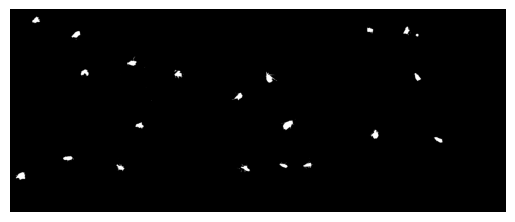

True

In [88]:
show(img_contours)
cv2.imwrite("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/examples/05_contours.jpg", img_contours,  [cv2.IMWRITE_JPEG_QUALITY, 25])


18 bounding boxes found.


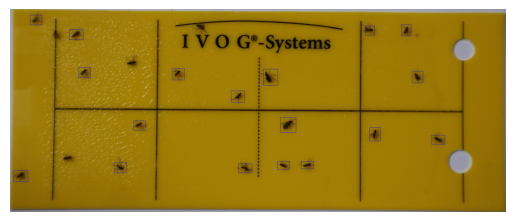

True

In [75]:
#original image with boxes
image = cv2.imread("/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/04_images_cropped/BRAIIM_0003.jpg")
min_area_contour = 2000 
max_area_contour = 10000
scale = 1.5
max_ratio = 1.73 #1.75 #95the percentile
upper_limit_rectangles = 42970 #41703 #95th percentil
value_threshold = None
binary_default = True

rectangles, v = get_list_of_rectangles(image_masked, min_area_contour, max_area_contour, scale, max_ratio, upper_limit_rectangles, value_threshold, binary_default)


img_rectangles = draw_bounding_boxes(image, rectangles)
show(img_rectangles)
cv2.imwrite("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/examples/06_w_labels.jpg", img_rectangles,  [cv2.IMWRITE_JPEG_QUALITY, 25])


36.0


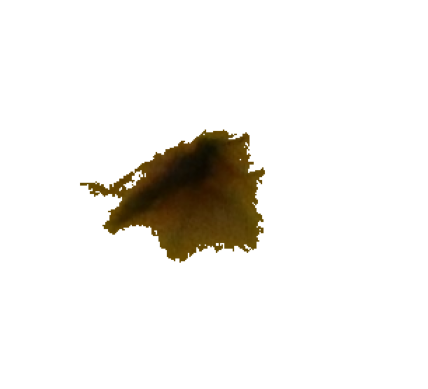

20.0


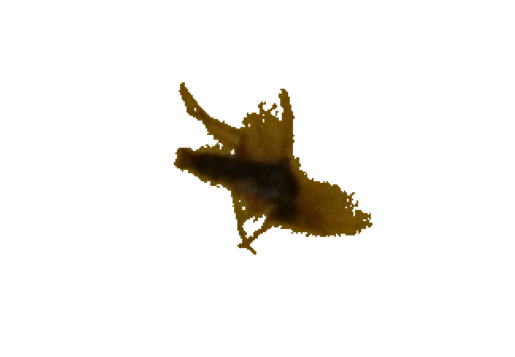

20.0


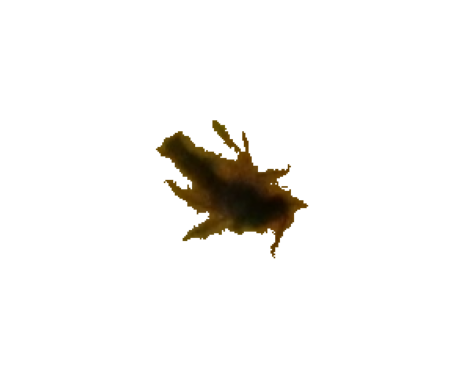

In [77]:
#cropped out insects
abs_boxes = []
with open("/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/05_created_labels/BRAIIM_0003.txt", 'r') as f:
    for line in f:
        if line.strip():
            x, y, w, h = map(float, ast.literal_eval(line))
            x1, y1, x2, y2 = x, y, x + w, y + h
            abs_boxes.append([x1, y1, x2, y2])

rectangles = [enlarge_box(box, image.shape, scale=1) for box in abs_boxes]

hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
insects = []

for i, box in enumerate(rectangles[:3]):
    x1, y1, x2, y2 = map(int, box)
    region_bgr = image[y1:y2, x1:x2]
    if region_bgr.size == 0:
        continue

    region_hsv = hsv_image[y1:y2, x1:x2]         

    value = region_hsv[:, :, 2]
    otsu_thresh, binary_mask = cv2.threshold(value, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    #binary_mask_inv = cv2.bitwise_not(binary_mask)
    
    hue = region_hsv[:, :, 0]

    t, hue_mask = cv2.threshold(hue, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    print(t)
    #hue_mask = cv2.bitwise_not(hue_mask)
    lower_yellow = np.array([18, 100, int(otsu_thresh)])
    upper_yellow = np.array([30, 255, 255])
    
    binary_mask = cv2.inRange(region_hsv, lower_yellow, upper_yellow)
    binary_mask_inv = cv2.bitwise_not(binary_mask)
    
    foreground = cv2.bitwise_and(region_bgr, region_bgr, mask=binary_mask_inv)
    background = np.full_like(region_bgr, 255)
    result = np.where(binary_mask_inv[:, :, np.newaxis] == 0, background, foreground)
    result = keep_central_contour(result)
    show(result)
    cv2.imwrite(f"/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/examples/insect{i}.jpg", result)


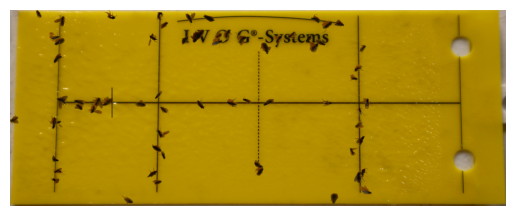

True

In [78]:
#YST with placed insects / augment 2
img = cv2.imread("/user/christoph.wald/u15287/big-scratch/04_SSL_training_data/training_data_full_images/images/train/BRAIIM_18_YST2_aug2.jpg")
show(img)
cv2.imwrite("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/examples/augment2.jpg", img,  [cv2.IMWRITE_JPEG_QUALITY, 25])


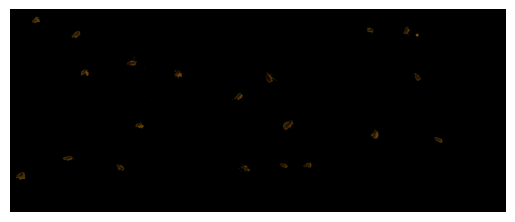

True

In [79]:
#background and foreground
# --- Create yellow/background mask from the image ---
yellow_mask = create_binary_mask(image_masked)  # 255 = background
yellow_mask_3c = cv2.merge([yellow_mask]*3)
foreground_layer = np.zeros_like(image_masked)
foreground_layer[yellow_mask_3c == 0] = image_masked[yellow_mask_3c == 0]

# --- Build the merged image ---
# Step 1: Background
background_layer = image_masked.copy()
background_layer[yellow_mask_3c == 0] = 0

show(foreground_layer)
cv2.imwrite("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/examples/a1_foreground.jpg", foreground_layer,  [cv2.IMWRITE_JPEG_QUALITY, 25])

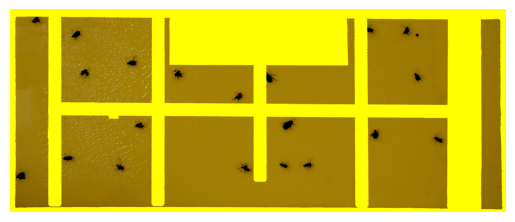

True

In [80]:
show(background_layer)
cv2.imwrite("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/examples/a2_background.jpg", background_layer,  [cv2.IMWRITE_JPEG_QUALITY, 25])

(3368, 6000, 3)


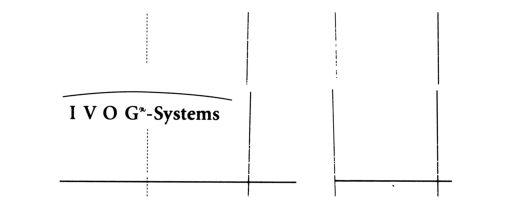

In [81]:
#circular shift mask

def crop(image):
    mask = create_binary_mask(image)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)
        cropped_image = image[y:y+h, x:x+w]
        return cropped_image, (x, y, w, h)
    else:
        return None, None
    

def fit_mask_to_image(mask, img_shape):
    """
    Resize/crop or place mask to fit the image shape.
    If mask is smaller: place randomly.
    If mask is larger: crop to fit.
    """
    mask_h, mask_w = mask.shape
    img_h, img_w = img_shape[:2]

    # If mask is larger, crop it
    if mask_h > img_h:
        start_y = (mask_h - img_h) // 2
        mask = mask[start_y:start_y+img_h, :]
    if mask_w > img_w:
        start_x = (mask_w - img_w) // 2
        mask = mask[:, start_x:start_x+img_w]

    # If mask is smaller, place it randomly
    mask_h, mask_w = mask.shape
    result_mask = np.ones((img_h, img_w), dtype=mask.dtype) * 255  # white background
    max_y = img_h - mask_h
    max_x = img_w - mask_w
    start_y = random.randint(0, max_y) if max_y > 0 else 0
    start_x = random.randint(0, max_x) if max_x > 0 else 0
    result_mask[start_y:start_y+mask_h, start_x:start_x+mask_w] = mask
    return result_mask

def circular_shift_mask_2d(mask, min_shift=500):
    h, w = mask.shape
    max_shift_h = h // 2
    max_shift_w = w // 2
    shift_y = random.randint(min_shift, max_shift_h) * random.choice([-1, 1])
    shift_x = random.randint(min_shift, max_shift_w) * random.choice([-1, 1])
    shifted_mask = np.roll(mask, shift_y, axis=0)
    shifted_mask = np.roll(shifted_mask, shift_x, axis=1)
    return shifted_mask

empty_folder = "/user/christoph.wald/u15287/big-scratch/emptyYST"
filename = os.listdir(empty_folder)[0]
img = cv2.imread(os.path.join(empty_folder, filename))
print(img.shape)
empty_YST, _ = crop(img)
mask = create_binary_mask(empty_YST)
cleaned_mask = denoise_mask(mask)
h, w = cleaned_mask.shape

top = 75
bottom = h - 100
left = 100
right = w * 4 // 5  # remove the rightmost 1/5

cleaned_mask = cleaned_mask[top:bottom, left:right]
mask0 = circular_shift_mask_2d(cleaned_mask)

mask0 = fit_mask_to_image(mask0, image_masked.shape)
cv2.imwrite("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/examples/a2_mask0.jpg", mask0,  [cv2.IMWRITE_JPEG_QUALITY, 25])
show(mask0)

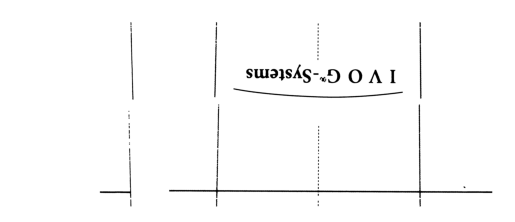

True

In [82]:
mask1 = circular_shift_mask_2d(cleaned_mask)
mask1 = cv2.rotate(mask1, cv2.ROTATE_180)
mask1 = fit_mask_to_image(mask1, image_masked.shape)
show(mask1)
cv2.imwrite("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/examples/a2_mask1.jpg", mask1,  [cv2.IMWRITE_JPEG_QUALITY, 25])

In [86]:
#augment 1
aug1 = cv2.imread("/user/christoph.wald/u15287/big-scratch/04_SSL_training_data/training_data_full_images/images/train/BRAIIM_0003.jpg")
cv2.imwrite("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/examples/augment1.jpg", aug1,  [cv2.IMWRITE_JPEG_QUALITY, 25])

True